# Data Cleaning & Visualization Project

## Project Objective

The objective of this project is to clean, process, analyze, and visualize a raw dataset to identify meaningful patterns and insights.

### Key Tasks
- Handle missing values
- Remove duplicate records
- Detect and handle outliers
- Correct data types
- Perform exploratory data analysis
- Create meaningful visualizations
- Identify important insights from the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
from google.colab import files

uploaded = files.upload()

Saving sales_data.csv to sales_data.csv


In [5]:
df = pd.read_csv("sales_data.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [7]:
df.head()

,Order_Date,Customer_Name,Product,Category,Region,Quantity,Unit_Price,Sales,Profit
0,2025-04-15,Customer_19,Tablet,Electronics,West,3.0,290.03,870.08,71.49
1,2025-02-19,Customer_78,Mouse,Accessories,North,1.0,27.63,27.63,6.33
2,2025-01-17,Customer_38,Printer,Office,NaN,7.0,189.30,1325.07,307.85
3,2025-03-28,Customer_96,Tablet,Electronics,NaN,1.0,342.90,342.90,55.62
4,2025-01-25,Customer_67,Keyboard,Accessories,West,8.0,40.68,325.45,71.37


In [8]:
df.tail()

,Order_Date,Customer_Name,Product,Category,Region,Quantity,Unit_Price,Sales,Profit
150,2025-04-02,Customer_32,Headphones,Accessories,East,8.0,90.65,725.23,194.98
151,2025-01-03,Customer_53,Headphones,Accessories,East,80.0,80.82,28000.00,8500.00
152,2025-01-11,Customer_81,Printer,Office,west,1.0,163.73,163.73,13.28
153,2025-04-02,Customer_62,Mouse,Accessories,North,9.0,26.83,241.48,52.21
154,2025-04-19,Customer_5,Phone,Electronics,East,10.0,508.42,5084.18,1287.38


In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 155
Number of columns: 9


In [10]:
df.shape

(155, 9)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_Date     155 non-null    object 
 1   Customer_Name  155 non-null    object 
 2   Product        155 non-null    object 
 3   Category       155 non-null    object 
 4   Region         151 non-null    object 
 5   Quantity       151 non-null    float64
 6   Unit_Price     155 non-null    float64
 7   Sales          155 non-null    float64
 8   Profit         151 non-null    float64
dtypes: float64(4), object(5)
memory usage: 11.0+ KB


In [12]:
df.describe()

,Quantity,Unit_Price,Sales,Profit
count,151.000000,155.000000,155.000000,151.000000
mean,7.119205,252.561161,1950.174645,449.055430
std,11.601682,218.739563,4989.656242,1399.983025
min,1.000000,21.550000,21.870000,4.060000
25%,3.000000,50.915000,280.455000,54.500000
50%,5.000000,198.200000,738.540000,129.730000
75%,8.000000,390.435000,1771.560000,318.735000
max,100.000000,744.770000,45000.000000,12000.000000


In [13]:
print(df.columns)

Index(['Order_Date', 'Customer_Name', 'Product', 'Category', 'Region',
       'Quantity', 'Unit_Price', 'Sales', 'Profit'],
      dtype='object')


In [14]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns)

Index(['order_date', 'customer_name', 'product', 'category', 'region',
       'quantity', 'unit_price', 'sales', 'profit'],
      dtype='object')


In [15]:
df.isnull().sum()

,0
order_date,0
customer_name,0
product,0
category,0
region,4
quantity,4
unit_price,0
sales,0
profit,4


In [16]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

order_date       0.000000
customer_name    0.000000
product          0.000000
category         0.000000
region           2.580645
quantity         2.580645
unit_price       0.000000
sales            0.000000
profit           2.580645
dtype: float64


In [20]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())

In [21]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

In [22]:
df.isnull().sum()

,0
order_date,0
customer_name,0
product,0
category,0
region,0
quantity,0
unit_price,0
sales,0
profit,0


In [23]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5


In [24]:
df = df.drop_duplicates()

print("Duplicates removed.")

Duplicates removed.


In [25]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


In [26]:
print(df.dtypes)

order_date        object
customer_name     object
product           object
category          object
region            object
quantity         float64
unit_price       float64
sales            float64
profit           float64
dtype: object


In [28]:
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")

In [29]:
numeric_columns = df.select_dtypes(include=np.number).columns

print(numeric_columns)

Index(['quantity', 'unit_price', 'sales', 'profit'], dtype='object')


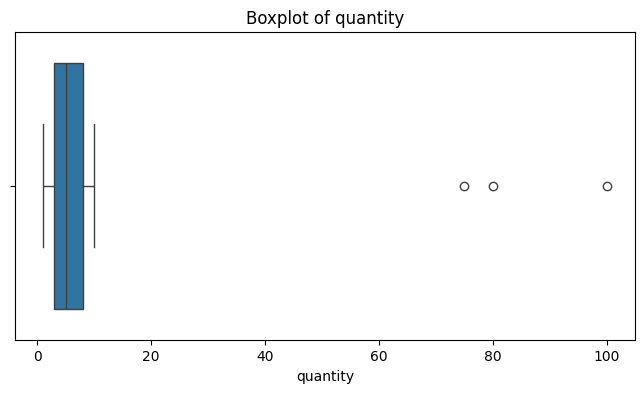

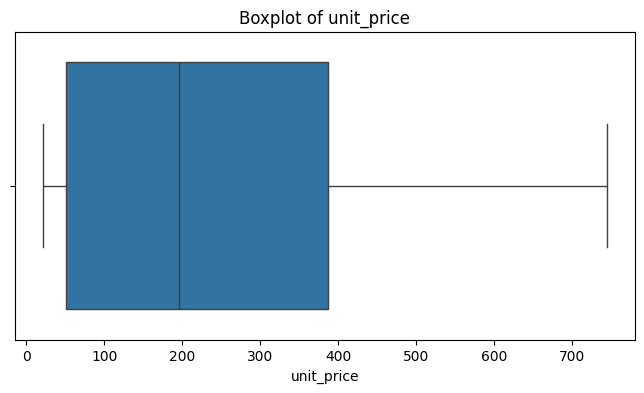

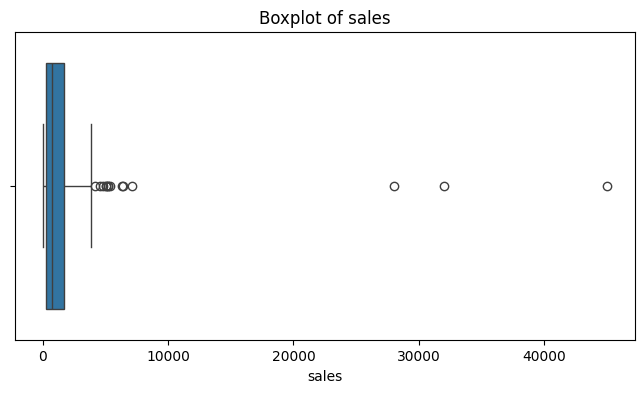

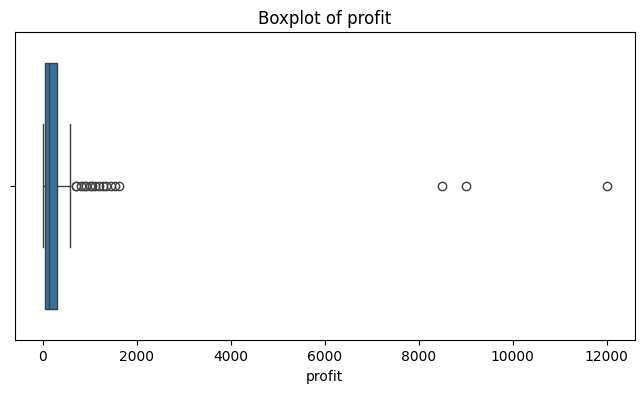

In [30]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f"Boxplot of {column}")
    plt.show()

In [31]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower_bound, upper_bound)

print("Outliers handled using IQR method.")

Outliers handled using IQR method.


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 0 to 154
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_date     150 non-null    object 
 1   customer_name  150 non-null    object 
 2   product        150 non-null    object 
 3   category       150 non-null    object 
 4   region         150 non-null    object 
 5   quantity       150 non-null    float64
 6   unit_price     150 non-null    float64
 7   sales          150 non-null    float64
 8   profit         150 non-null    float64
dtypes: float64(4), object(5)
memory usage: 11.7+ KB


In [33]:
df.describe()

,quantity,unit_price,sales,profit
count,150.000000,150.000000,150.000000,150.000000
mean,5.716667,249.204600,1213.075567,218.057158
std,3.174678,216.036273,1179.567331,215.943749
min,1.000000,21.550000,21.870000,4.060000
25%,3.000000,50.637500,280.187500,54.975000
50%,5.000000,196.595000,731.885000,129.730000
75%,8.000000,386.752500,1719.297500,310.662500
max,15.500000,744.770000,3877.962500,694.193750


In [34]:
df.head()

,order_date,customer_name,product,category,region,quantity,unit_price,sales,profit
0,2025-04-15,Customer_19,Tablet,Electronics,West,3.0,290.03,870.08,71.49
1,2025-02-19,Customer_78,Mouse,Accessories,North,1.0,27.63,27.63,6.33
2,2025-01-17,Customer_38,Printer,Office,North,7.0,189.30,1325.07,307.85
3,2025-03-28,Customer_96,Tablet,Electronics,North,1.0,342.90,342.90,55.62
4,2025-01-25,Customer_67,Keyboard,Accessories,West,8.0,40.68,325.45,71.37


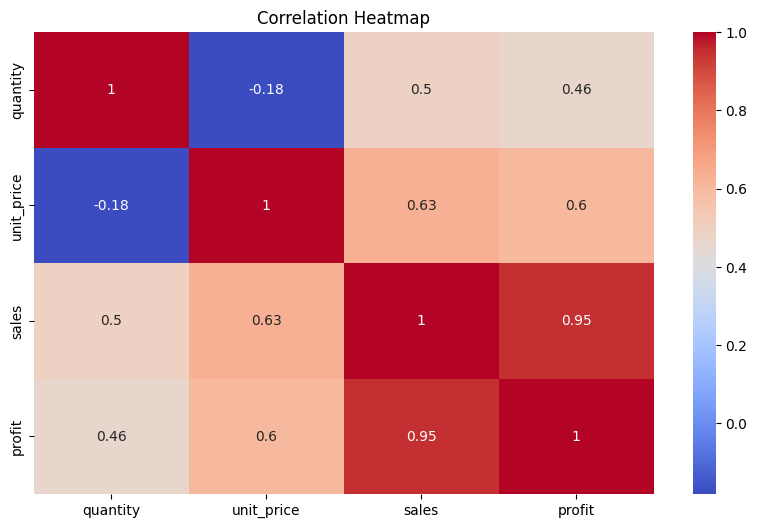

In [35]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

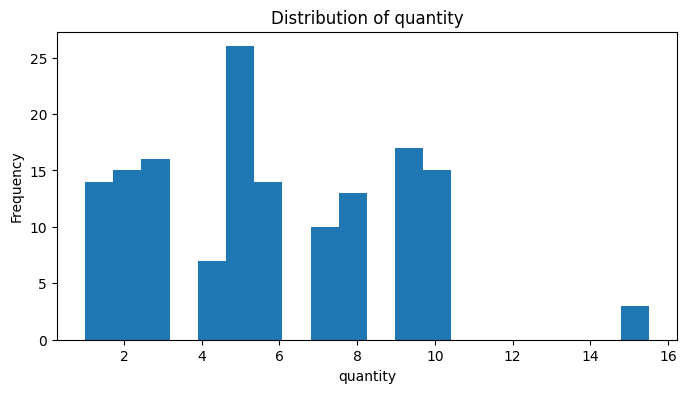

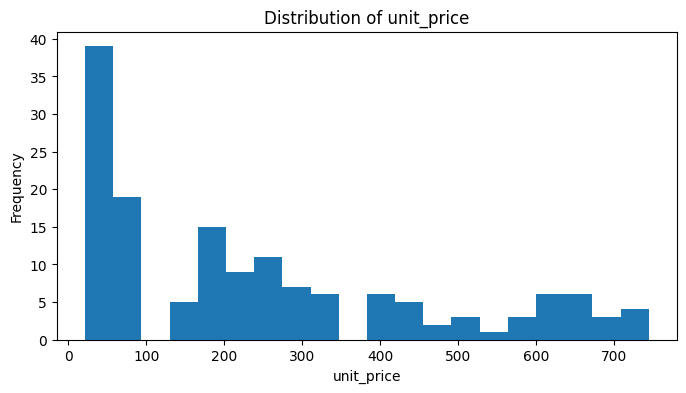

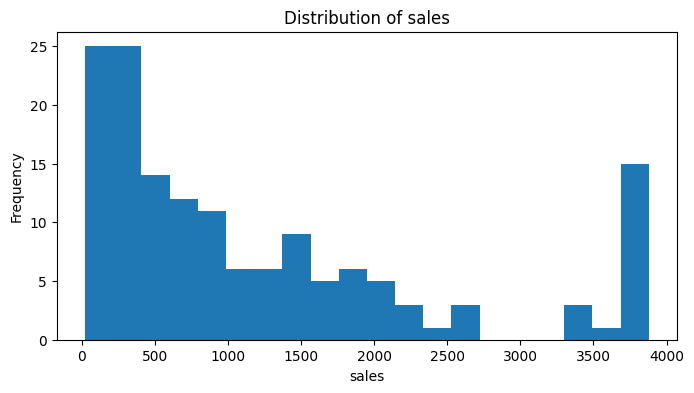

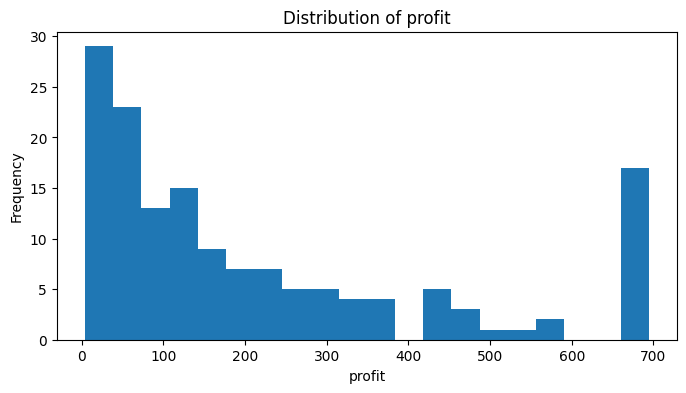

In [36]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    plt.hist(df[column], bins=20)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

In [37]:
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['order_date', 'customer_name', 'product', 'category', 'region'], dtype='object')


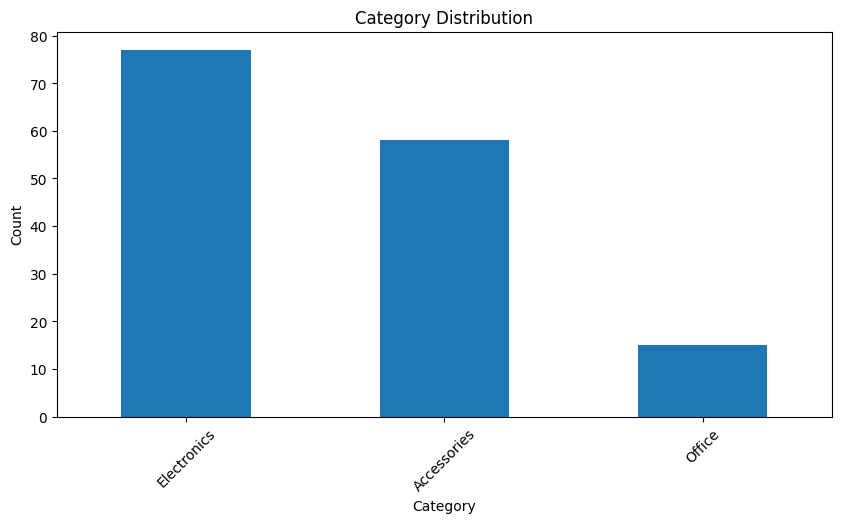

In [38]:
plt.figure(figsize=(10, 5))

df["category"].value_counts().plot(kind="bar")

plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

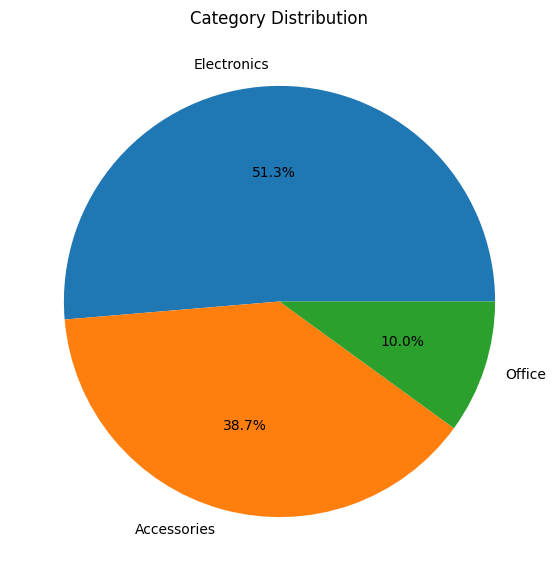

In [39]:
df["category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7, 7)
)

plt.title("Category Distribution")
plt.ylabel("")
plt.show()

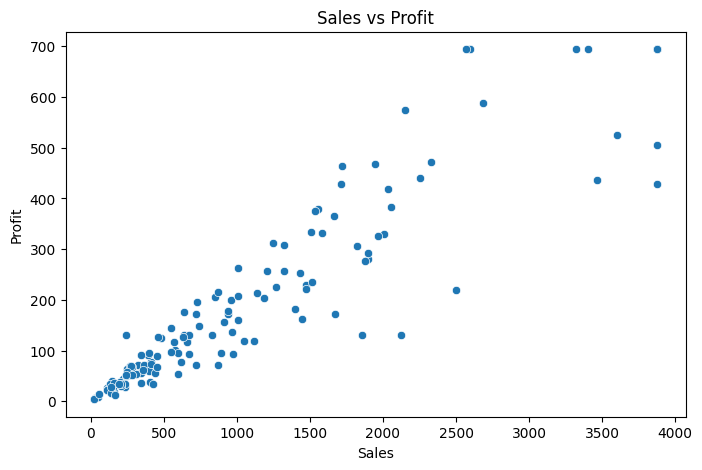

In [40]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="sales",
    y="profit"
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

In [41]:
df.describe()

,quantity,unit_price,sales,profit
count,150.000000,150.000000,150.000000,150.000000
mean,5.716667,249.204600,1213.075567,218.057158
std,3.174678,216.036273,1179.567331,215.943749
min,1.000000,21.550000,21.870000,4.060000
25%,3.000000,50.637500,280.187500,54.975000
50%,5.000000,196.595000,731.885000,129.730000
75%,8.000000,386.752500,1719.297500,310.662500
max,15.500000,744.770000,3877.962500,694.193750


In [42]:
print("Mean values:")
print(df.select_dtypes(include=np.number).mean())

Mean values:
quantity         5.716667
unit_price     249.204600
sales         1213.075567
profit         218.057158
dtype: float64


# Key Insights

Based on the data analysis and visualizations, the following insights were identified:

1. The dataset contained missing values, which were handled using appropriate statistical methods.
2. Duplicate records were identified and removed.
3. Outliers were detected using the IQR method and handled appropriately.
4. The visualizations helped identify patterns and distributions in the dataset.
5. The correlation heatmap helped identify relationships between numerical variables.
6. Categorical analysis showed the distribution of different categories.
7. The analysis provides useful information that can support data-driven decision making.

In [43]:
df.to_csv("cleaned_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [45]:
files.download("cleaned_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusion

This project demonstrated the complete process of data preprocessing, exploratory data analysis, and data visualization.

The raw dataset was cleaned by handling missing values, removing duplicate records, correcting data types, and identifying and handling outliers.

Different visualization techniques such as bar charts, histograms, boxplots, scatter plots, and correlation heatmaps were used to understand the data and identify meaningful patterns.

Overall, this project provided practical experience in using Python, Pandas, Matplotlib, and Seaborn for data cleaning, analysis, visualization, and data storytelling.